Comparing the kinetic between different upper potential limit

In [1]:
# Importing the necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy
import scipy
from datetime import datetime
from scipy.integrate import solve_ivp
from model.kinetic_eq import *

In [2]:
# Global variables
n_group_ptParticle = 50
rmin = 1e-8
rmax = 1e-6
dr = 1e-6 / n_group_ptParticle
r_m = (np.linspace(rmin, rmax, n_group_ptParticle + 1) + dr / 2)[1:]
Tfc = 273.15+55
#drive_data = pd.read_csv('50_h.csv', header=0, index_col=0)

In [3]:
def initPRD(resolution=200, rmin=1e-8, rmax=1e-6, std=0.549, mu=0.538):
    radius = np.linspace(rmin, rmax, resolution)
    pdf_values = scipy.stats.norm.pdf(np.log(radius * 1e7), mu, std)
    return pdf_values

def ucell_sw(t):

    t = t%40
    UPL = 0.98
    LPL = 0.6
    t_stop = 40
    iload_rise =  (UPL - LPL)/2 * np.tanh(t - t_stop / 4) + LPL/2
    iload_drop =  -(UPL - LPL)/2 * np.tanh(t - t_stop * 3 / 4) +LPL/2
    return (iload_rise  + iload_drop)

def ucell_tw(t):
    UPL = 0.98
    LPL = 0.6
    v_scan = 0.0125
    u = (UPL-LPL)/np.pi*np.arcsin(np.sin((np.pi*v_scan)/(UPL-LPL)*t-np.pi/2))+(UPL-LPL)/2+LPL
    return u

def Cproton_CCL(lambda_w, EW=1.1, rho_mem=0.002):
    """
    Concentration of proton based on the membrane water content(humidity)
    Darling et al. 2023
    :param EW: Equivalent weight of dry membrane.
    :param rho_mem: Membrane dry density
    :return: concentration of H+
    """
    if type(lambda_w) == float:
        rho_H2O = 997  # (kg/m3)
        M_H2O = 18.02e-3  # kg/mol
        return 1 / ((EW / rho_mem) + lambda_w * (M_H2O / rho_H2O))
    else:
        return 0

class ccl():

    def __init__(self):
        self.Ucell = ucell_sw
        self.prd0 = initPRD(resolution=n_group_ptParticle)


    def dxdt(self, t, x):

        C_Pt2_ccl = x[0]
        theta_CCL = x[1:1+len(r_m)]
        prd = x[-len(r_m):]
        u = self.Ucell(t)

        # CCL kinetic
        C_H_CCL = Cproton_CCL(lambda_w=6.0)
        kdis = PtDissolution(u, Tfc, C_Pt2_ccl, theta_CCL)
        kox = PtOxidation(u, Tfc, C_H_CCL, theta_CCL)
        kcdis = PtOxideDissolution(theta_CCL, C_H_CCL)
        kdet = PtDetachment(u, Tfc, r_m)
        drdt = Vm_Pt * krdp * C_Pt2_ccl * np.exp(R0 / r_m) - Vm_Pt * (kdis + kox) * Cpt2_ref * np.exp(R0 / r_m)
        M_Pt0 = 4 / 3 * np.pi * rho_Pt * np.trapz(y=self.prd0 * r_m ** 3, x=r_m)
        dMdisdt = 4 * np.pi * rho_Pt * np.trapz(y=prd * r_m ** 2 * drdt, x=r_m)
        dMcdisdt = 4 * np.pi * rho_Pt * np.trapz(y=prd * r_m ** 2 * kcdis, x=r_m)
        dC_Pt2_ccl = -3.33 / M_Pt * (dMdisdt - dMcdisdt) / M_Pt0
        dfdt = -np.gradient(prd * drdt, r_m) - kdet * prd
        dthetadt = (((kox - kcdis) / GAMMA_max) - (2 * theta_CCL / r_m) * drdt)

        dxdt = [0]*(1+len(r_m)*2)
        dxdt[0] = dC_Pt2_ccl
        dxdt[1:1+len(r_m)] = dthetadt
        dxdt[-len(r_m):] = dfdt

        return dxdt

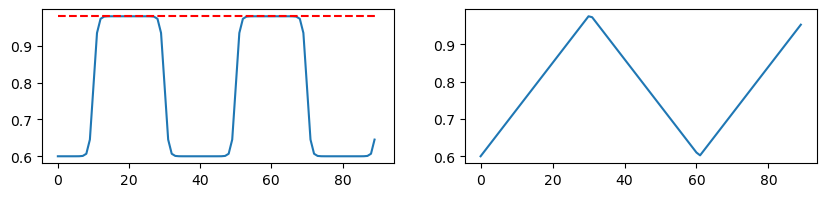

In [4]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(10,2))
ax[0].plot(ucell_sw(np.arange(0,90,1)))
ax[0].hlines(0.98,0,90,linestyle='--',color='#FF0000')
ax[1].plot(ucell_tw(np.arange(0,90,1)))

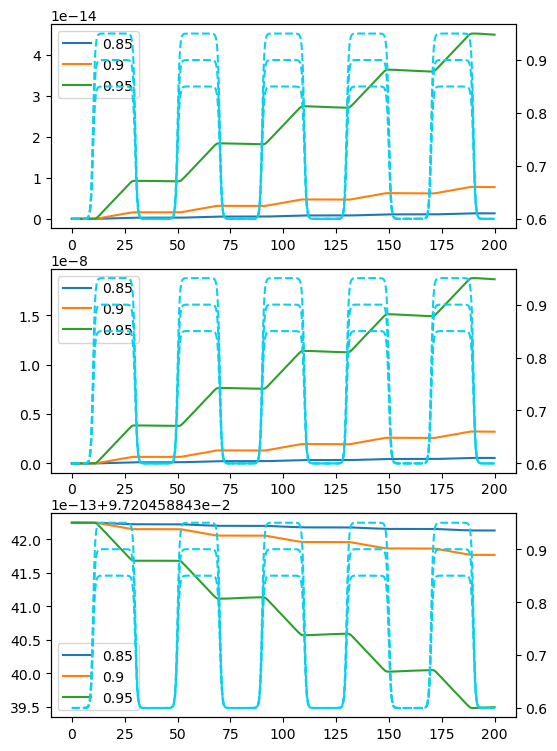

In [5]:
t_end = 200
sol_hist = []
vol_hist = []
upl_list = [0.85, 0.9, 0.95]

for upl in upl_list:
    def ucell_sw(t):
        t = t%40
        UPL = upl
        LPL = 0.6
        t_stop = 40
        iload_rise =  (UPL - LPL)/2 * np.tanh(t - t_stop / 4) + LPL/2
        iload_drop =  -(UPL - LPL)/2 * np.tanh(t - t_stop * 3 / 4) +LPL/2
        return iload_rise  + iload_drop
    model = ccl()
    model.Ucell = ucell_sw
    x_init = [0] + [0]*len(r_m) + model.prd0.tolist()
    sol = solve_ivp(fun=model.dxdt, y0 = x_init, t_span=(0, t_end), max_step = 1e-1, method='BDF')
    sol_hist.append(sol)
    vol_hist.append([ucell_sw(t) for t in sol.t])

fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(6,9))
ax1_twin = ax[0].twinx()
ax2_twin = ax[1].twinx()
ax3_twin = ax[2].twinx()
for i_sol in range(len(sol_hist)):
    ax[0].plot(sol_hist[i_sol].t, sol_hist[i_sol].y[0,:], label=upl_list[i_sol])
    ax[1].plot(sol_hist[i_sol].t, sol_hist[i_sol].y[25,:], label=upl_list[i_sol])
    ax[2].plot(sol_hist[i_sol].t, sol_hist[i_sol].y[-25,:], label=upl_list[i_sol])
    ax1_twin.plot(sol_hist[i_sol].t, vol_hist[i_sol], color = '#0AD0EF', linestyle = '--')
    ax2_twin.plot(sol_hist[i_sol].t, vol_hist[i_sol], color = '#0AD0EF', linestyle = '--')
    ax3_twin.plot(sol_hist[i_sol].t, vol_hist[i_sol], color = '#0AD0EF', linestyle = '--')

ax[0].legend(loc='best')
ax[1].legend(loc='best')
ax[2].legend(loc='best')

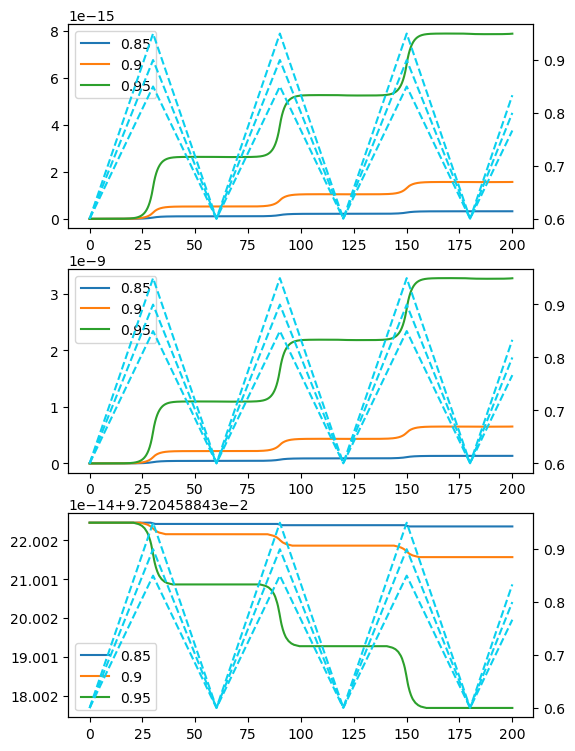

In [6]:
t_end = 200
sol_hist = []
vol_hist = []
upl_list = [0.85, 0.9, 0.95]
for upl in upl_list:
    def ucell_tw(t):
        UPL = upl
        LPL = 0.6
        v_scan = (UPL-LPL)/30
        u = (UPL-LPL)/np.pi*np.arcsin(np.sin((np.pi*v_scan)/(UPL-LPL)*t-np.pi/2))+(UPL-LPL)/2+LPL
        return u
    model = ccl()
    model.Ucell = ucell_tw
    x_init = [0] + [0]*len(r_m) + model.prd0.tolist()
    sol = solve_ivp(fun=model.dxdt, y0 = x_init, t_span=(0, t_end), max_step = 1e-1, method='BDF')
    sol_hist.append(sol)
    vol_hist.append([ucell_tw(t) for t in sol.t])

fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(6,9))
ax1_twin = ax[0].twinx()
ax2_twin = ax[1].twinx()
ax3_twin = ax[2].twinx()
for i_sol in range(len(sol_hist)):
    ax[0].plot(sol_hist[i_sol].t, sol_hist[i_sol].y[0,:], label=upl_list[i_sol])
    ax[1].plot(sol_hist[i_sol].t, sol_hist[i_sol].y[25,:], label=upl_list[i_sol])
    ax[2].plot(sol_hist[i_sol].t, sol_hist[i_sol].y[-25,:], label=upl_list[i_sol])
    ax1_twin.plot(sol_hist[i_sol].t, vol_hist[i_sol], color = '#0AD0EF', linestyle = '--')
    ax2_twin.plot(sol_hist[i_sol].t, vol_hist[i_sol], color = '#0AD0EF', linestyle = '--')
    ax3_twin.plot(sol_hist[i_sol].t, vol_hist[i_sol], color = '#0AD0EF', linestyle = '--')

ax[0].legend(loc='best')
ax[1].legend(loc='best')
ax[2].legend(loc='best')